# Practical Session 02b &mdash; The closed-form solution: normal equations & geometry

**Companion to Lecture&nbsp;02.** In 02a we saw the least-squares cost is a convex **bowl** and
that brute force cannot find its bottom past a couple of parameters. This notebook finds the
bottom **exactly, with a formula** &mdash; the *normal equations* &mdash; derived, implemented from
scratch in NumPy, checked against the parameters that generated the data *and* against
scikit-learn, and then explained by a beautiful piece of geometry: **projection onto the column
space**.

> ⭐ **Key idea.** The best-fit parameters solve $\mathbf{X}^{\!\top}\mathbf{X}\,\boldsymbol\theta
> = \mathbf{X}^{\!\top}\mathbf{y}$ &mdash; the **normal equations** &mdash; whose meaning is purely
> geometric: the prediction $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol\theta$ is the point in the
> span of the feature columns that is **closest** to $\mathbf{y}$, i.e. its orthogonal
> **projection**, and the residual is perpendicular to that span.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_regression_1d, make_regression_md

use_style("notes")
np.set_printoptions(precision=3, suppress=True)
print("ready")

ready


## 1. Setup: the design matrix and the cost

Recall from 02a: stack a column of ones (for the intercept) next to the features to form the
**design matrix** $\mathbf{X}\in\mathbb{R}^{n\times p}$, gather the parameters into
$\boldsymbol\theta\in\mathbb{R}^{p}$, and write predictions and cost compactly:

$$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol\theta,\qquad
J(\boldsymbol\theta) = \tfrac1n\lVert \mathbf{X}\boldsymbol\theta - \mathbf{y}\rVert^2.$$

In [2]:
x, y = make_regression_1d(n=40, seed=0)           # true line: w0 = 3.0, w1 = 2.0
X = np.column_stack([np.ones_like(x), x])         # design matrix [1, x], shape (n, 2)
print("X shape:", X.shape, "| first rows:\n", X[:3])

X shape: (40, 2) | first rows:
 [[1.    0.014]
 [1.    0.083]
 [1.    0.142]]


## 2. Setting the gradient to zero

At the bottom of the bowl the gradient vanishes. Differentiating
$J(\boldsymbol\theta) = \tfrac1n(\mathbf{X}\boldsymbol\theta - \mathbf{y})^{\!\top}
(\mathbf{X}\boldsymbol\theta - \mathbf{y})$ with respect to $\boldsymbol\theta$ gives

$$\nabla J(\boldsymbol\theta) = \tfrac{2}{n}\,\mathbf{X}^{\!\top}(\mathbf{X}\boldsymbol\theta - \mathbf{y}).$$

Setting it to zero and cancelling the constant yields the **normal equations**

$$\mathbf{X}^{\!\top}\mathbf{X}\,\boldsymbol\theta = \mathbf{X}^{\!\top}\mathbf{y}
\qquad\Longrightarrow\qquad
\boxed{\;\boldsymbol\theta = (\mathbf{X}^{\!\top}\mathbf{X})^{-1}\mathbf{X}^{\!\top}\mathbf{y}\;}$$

a single linear system &mdash; no search, no iteration.

In [3]:
# the formula, step by step, in NumPy
XtX = X.T @ X                 # (p, p)
Xty = X.T @ y                 # (p,)
theta = np.linalg.inv(XtX) @ Xty
print("XtX =\n", XtX)
print("Xty =", Xty)
print("\ntheta_hat = [w0, w1] =", theta)
print("true line was          = [3.0, 2.0]")

XtX =
 [[ 40.    107.336]
 [107.336 378.529]]
Xty = [ 352.74  1116.496]

theta_hat = [w0, w1] = [3.779 1.878]
true line was          = [3.0, 2.0]


The formula recovers the intercept and slope directly &mdash; and they land right on top of the
true generating values (up to the noise). That is the whole method in three matrix operations.

> 🔬 **Going deeper (why *squared* error?).** Suppose each target is the true line plus
> independent Gaussian noise, $y_i = \mathbf{x}_i^{\!\top}\boldsymbol\theta + \varepsilon_i$ with
> $\varepsilon_i \sim \mathcal{N}(0,\sigma^2)$. The likelihood of the data is
> $\prod_i \frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\big(-\frac{(y_i-\mathbf{x}_i^{\!\top}\boldsymbol\theta)^2}{2\sigma^2}\big)$.
> Its logarithm turns the product into a sum and drops the constants, leaving
> $-\frac{1}{2\sigma^2}\sum_i (y_i-\mathbf{x}_i^{\!\top}\boldsymbol\theta)^2$. So **maximizing the
> likelihood is exactly minimizing the sum of squared residuals**: least squares *is* maximum
> likelihood under Gaussian noise. That is the principled reason we square &mdash; and it hints that
> other noise models give other losses (Laplace noise $\to$ absolute error, an outlier-robust fit;
> see 02d).

## 3. Three ways to solve it &mdash; and which to trust

`inv(XtX) @ Xty` matches the textbook formula but is the *least* numerically stable way (forming
and inverting $\mathbf{X}^{\!\top}\mathbf{X}$ squares the conditioning). Two better options:

In [4]:
theta_inv   = np.linalg.inv(XtX) @ Xty          # textbook, least stable
theta_solve = np.linalg.solve(XtX, Xty)         # better: solve the system, never invert
theta_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]   # best: solve least-squares from X directly

print("inv   :", theta_inv)
print("solve :", theta_solve)
print("lstsq :", theta_lstsq)
print("\nall three agree:", np.allclose(theta_inv, theta_solve) and np.allclose(theta_solve, theta_lstsq))

inv   : [3.779 1.878]
solve : [3.779 1.878]
lstsq : [3.779 1.878]

all three agree: True


> 🔬 **Going deeper.** All three give the same answer on well-behaved data, but they differ when
> $\mathbf{X}^{\!\top}\mathbf{X}$ is *ill-conditioned* (Section&nbsp;7). Rule of thumb:
> **`np.linalg.lstsq`** (or `scikit-learn`, which uses it) &mdash; it works straight from
> $\mathbf{X}$, avoids forming $\mathbf{X}^{\!\top}\mathbf{X}$, and returns a sensible answer even
> when the system is rank-deficient. Reach for `inv` only to mirror the math, never in production.

## 4. Cross-check against scikit-learn

`LinearRegression` solves exactly this least-squares problem (it handles the intercept
separately, so compare its `intercept_` to our $w_0$ and its `coef_` to our $w_1$).

In [5]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"our theta   : w0 = {theta[0]:.6f}   w1 = {theta[1]:.6f}")
print(f"sklearn     : w0 = {sk.intercept_:.6f}   w1 = {sk.coef_[0]:.6f}")
print("match:", np.allclose([sk.intercept_, sk.coef_[0]], theta))

our theta   : w0 = 3.779459   w1 = 1.877855
sklearn     : w0 = 3.779459   w1 = 1.877855
match: True


## 5. Many features at once &mdash; recovering the truth

Nothing above assumed a single feature. With $d$ features the design matrix has $d+1$ columns
(the ones + the features) and the *same* formula applies. To prove the implementation is right,
generate data from **known** coefficients and check that we recover them.

In [6]:
Xmd, ymd, w_true, b_true = make_regression_md(n=300, d=5, seed=1, noise=2.0)
Xb = np.column_stack([np.ones(len(Xmd)), Xmd])          # add the bias column
theta_md = np.linalg.lstsq(Xb, ymd, rcond=None)[0]      # [b, w1..w5]

print("recovered bias   :", theta_md[0].round(3), "   true bias   :", round(b_true, 3))
print("recovered weights:", theta_md[1:].round(3))
print("true weights     :", w_true.round(3))

sk = LinearRegression().fit(Xmd, ymd)
print("\nsklearn weights  :", sk.coef_.round(3), "| bias:", round(sk.intercept_, 3))
print("our fit == sklearn:", np.allclose(theta_md[1:], sk.coef_) and np.isclose(theta_md[0], sk.intercept_))

recovered bias   : 1.565    true bias   : 1.5
recovered weights: [-0.245  1.969 -2.668 -0.819 -0.553]
true weights     : [-0.405  1.84  -2.496 -0.794 -0.344]

sklearn weights  : [-0.245  1.969 -2.668 -0.819 -0.553] | bias: 1.565
our fit == sklearn: True


The recovered coefficients sit right on the true ones (the small gaps are the injected noise),
and they match scikit-learn to machine precision. The from-scratch solver is correct.

## 6. The geometry: least squares is a projection

Here is *why* the normal equations look the way they do. Think of the target $\mathbf{y}$ as a
single point in $\mathbb{R}^{n}$ (one axis per data point). Every possible prediction
$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol\theta$ is a combination of the **columns** of
$\mathbf{X}$, so it is stuck inside their span &mdash; the **column space**, a flat subspace. Least
squares picks the $\hat{\mathbf{y}}$ in that subspace **closest** to $\mathbf{y}$: its
**orthogonal projection**. Closest means the residual $\mathbf{r} = \mathbf{y} - \hat{\mathbf{y}}$
is perpendicular to the subspace, i.e. to every column: $\mathbf{X}^{\!\top}\mathbf{r} = \mathbf{0}$
&mdash; which rearranges into the normal equations.

In [7]:
# verify orthogonality on the real fit: X^T r should be (numerically) zero
r = y - X @ theta
print("X^T r =", (X.T @ r), " -> essentially zero: residual is perpendicular to every column")

X^T r = [0. 0.]  -> essentially zero: residual is perpendicular to every column


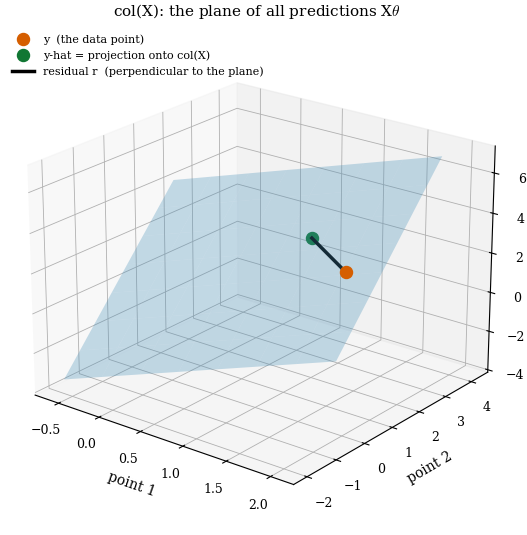

In [8]:
# a picture in R^3: 3 data points, so y is a point in 3-D; col(X) is a 2-D plane through 0.
xp = np.array([0.0, 1.0, 2.0])
Xp = np.column_stack([np.ones(3), xp])                 # columns span a 2-D plane in R^3
normal = np.cross(Xp[:, 0], Xp[:, 1]); normal /= np.linalg.norm(normal)   # unit normal to the plane
yhat = Xp @ np.array([1.0, 1.0])                       # a point ON the plane (= the projection)
yp = yhat + 2.6 * normal                               # push the data point clearly OFF the plane
th = np.linalg.lstsq(Xp, yp, rcond=None)[0]            # least squares recovers exactly that projection
assert np.allclose(Xp @ th, yhat)

fig = plt.figure(figsize=(6.6, 5.4)); ax = fig.add_subplot(projection="3d")
S, T = np.meshgrid(np.linspace(-0.6, 1.8, 8), np.linspace(-1.4, 2.4, 8))
P = S[..., None] * Xp[:, 0] + T[..., None] * Xp[:, 1]  # all s*c0 + t*c1 fill the column space
ax.plot_surface(P[..., 0], P[..., 1], P[..., 2], alpha=0.30, color="#56B4E9")
ax.scatter(*yp, color="#D55E00", s=75, label="y  (the data point)")
ax.scatter(*yhat, color="#117733", s=75, label="y-hat = projection onto col(X)")
ax.plot(*np.column_stack([yhat, yp]), color="black", lw=2.5,
        label="residual r  (perpendicular to the plane)")
ax.set_title("col(X): the plane of all predictions X$\\theta$", fontsize=11)
ax.set_xlabel("point 1"); ax.set_ylabel("point 2"); ax.set_zlabel("point 3")
ax.view_init(elev=22, azim=-52); ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.show()

> 💡 **Intuition.** Shine a light straight down onto the plane: the shadow of $\mathbf{y}$ is
> $\hat{\mathbf{y}}$, and the vertical drop is the residual $\mathbf{r}$. No other point on the
> plane is closer to $\mathbf{y}$, which is exactly what "least squares" means. The normal
> equations are just the algebra of "$\mathbf{r}$ is perpendicular to the plane."

## 7. When the formula breaks: collinear features

If two columns of $\mathbf{X}$ are the same (or linear combinations of each other), the column
space does not gain a dimension, $\mathbf{X}^{\!\top}\mathbf{X}$ is **singular**, and
$(\mathbf{X}^{\!\top}\mathbf{X})^{-1}$ does not exist &mdash; the exact *dummy-variable trap* from
notebook 01e. The parameters are no longer unique (many $\boldsymbol\theta$ give the same
prediction), though the prediction itself is still well-defined.

In [9]:
Xcol = np.column_stack([np.ones_like(x), x, x])    # feature x included TWICE -> rank deficient
XtX_c = Xcol.T @ Xcol
print("det(X^T X) =", np.linalg.det(XtX_c), " (essentially 0 -> singular)")

try:
    np.linalg.solve(XtX_c, Xcol.T @ y)
except np.linalg.LinAlgError as e:
    print("solve() / inv() fails:", e)

theta_c = np.linalg.lstsq(Xcol, y, rcond=None)[0]  # lstsq still returns the minimum-norm solution
print("lstsq minimum-norm solution:", theta_c, " (splits the slope across the two copies)")
print("predictions still fine? R^2 vs single-feature fit:",
      np.allclose(Xcol @ theta_c, X @ theta))

det(X^T X) = 0.0  (essentially 0 -> singular)
solve() / inv() fails: Singular matrix
lstsq minimum-norm solution: [3.779 0.939 0.939]  (splits the slope across the two copies)
predictions still fine? R^2 vs single-feature fit: True


> ⚠️ **Watch out.** `inv`/`solve` blow up on collinear features; `lstsq`/`pinv` degrade
> gracefully to the **minimum-norm** solution. The principled cure is **regularization** &mdash;
> adding $\lambda\mathbf{I}$ makes $\mathbf{X}^{\!\top}\mathbf{X}+\lambda\mathbf{I}$ invertible
> again (ridge regression, previewed in 02d and the whole of Session&nbsp;03).

## 8. So why ever iterate?

The closed form is exact and fast for modest problems. But solving the normal equations costs on
the order of $O(d^3)$ for $d$ features (forming and factoring a $d\times d$ system), which becomes
impractical when $d$ is very large, and it requires all the data in memory at once. It also does
not generalize to models with **no** closed form (logistic regression, neural nets). The remedy
is to walk down the bowl instead of jumping &mdash; **gradient descent**, the subject of 02c.

## Recap & exercises

**Recap.**
* Setting $\nabla J = 0$ gives the **normal equations**
  $\mathbf{X}^{\!\top}\mathbf{X}\,\boldsymbol\theta = \mathbf{X}^{\!\top}\mathbf{y}$, solved by
  $\boldsymbol\theta = (\mathbf{X}^{\!\top}\mathbf{X})^{-1}\mathbf{X}^{\!\top}\mathbf{y}$.
* Prefer **`np.linalg.lstsq`** over `inv`; it is stabler and handles rank-deficiency.
* The from-scratch solver recovers **known** coefficients and matches **scikit-learn** exactly.
* Geometrically, $\hat{\mathbf{y}}$ is the **orthogonal projection** of $\mathbf{y}$ onto the
  column space, and $\mathbf{X}^{\!\top}\mathbf{r} = \mathbf{0}$ *is* the normal equations.
* **Collinear** features make $\mathbf{X}^{\!\top}\mathbf{X}$ singular (non-unique parameters);
  `lstsq`/ridge fix it. Large $d$ makes the $O(d^3)$ solve costly &mdash; motivating gradient descent.

**Exercises.**
1. Write a one-line `fit_normal(X, y)` that adds the bias column and returns
   $\boldsymbol\theta$ via `lstsq`. Test it recovers $(3, 2)$ on `make_regression_1d`.
2. Verify $\mathbf{X}^{\!\top}\mathbf{r} = \mathbf{0}$ for the multivariate fit of Section&nbsp;5.
   How close to zero (in max-abs) is it?
3. Time `inv`, `solve`, and `lstsq` on `make_regression_md(n=2000, d=200)` with `%timeit`.
   Which is fastest? Do the answers still agree?
4. Add a third, *noisy* copy of `x` (`x + 1e-6*randn`) instead of an exact copy. Is
   $\mathbf{X}^{\!\top}\mathbf{X}$ singular now? Look at `np.linalg.cond(XtX)` &mdash; what does a huge
   condition number tell you?
5. Implement ridge from scratch: $\boldsymbol\theta = (\mathbf{X}^{\!\top}\mathbf{X} +
   \lambda\mathbf{I})^{-1}\mathbf{X}^{\!\top}\mathbf{y}$ and confirm it *is* invertible on the
   collinear data of Section&nbsp;7 for $\lambda>0$.

*Next:* **02c &mdash; gradient descent from scratch**: reach the bottom of the bowl by walking
downhill, and meet the two knobs that decide whether you get there &mdash; the learning rate and
feature scaling.